In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from statsmodels.stats.anova import AnovaRM
import statsmodels.formula.api as smf

In [60]:
def cohen_glass_hedges(x,y):
    nx = len(x)
    ny = len(y)
    pstdnmr = (nx-1)*x.var(ddof=1) + (ny-1)*y.var(ddof=1)   # (n-1)(var1+var2)
    pstddnm = nx + ny - 2                                   # (n-1)*2
    pstd = (pstdnmr / pstddnm)**(0.5)
    cohen = (x.mean() - y.mean()) / pstd
    glass = (x.mean() - y.mean()) / x.std(ddof=1)
    hedges = cohen * (1 - 3/(4 * (nx+ny) - 9) )             # cohen * (1-3/(8*n-9))
    return (cohen, glass, hedges)

In [2]:
w = pd.read_csv('ws.csv')

In [3]:
w.id = w.id.str.replace('w', '')

In [4]:
wm = w.melt(id_vars=['Index', 'id', 'group', 'time', 'rank', 'total'], 
            value_vars=w.columns[6:],
            var_name='step',
            value_name='val')

In [51]:
AnovaRM(data=wm, depvar='val',
                 subject='id',
                 within=['time', 'step']).fit().summary()

,F Value,Num DF,Den DF,Pr > F
time,0.6578,1.0000,39.0000,0.4223
step,1.8220,18.0000,702.0000,0.0196
time:step,0.9587,18.0000,702.0000,0.5065


In [18]:
smf.mixedlm("val ~ time", wm, groups=wm["id"], vc_formula={"step": "0 + C(step)"}).fit().summary()

/home/thal/.0/STATS/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:             MixedLM  Dependent Variable:  val     
No. Observations:  1520     Method:              REML    
No. Groups:        40       Scale:               0.0448  
Min. group size:   38       Log-Likelihood:      167.7710
Max. group size:   38       Converged:           Yes     
Mean group size:   38.0                                  
---------------------------------------------------------
                Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       0.628    0.008 80.283 0.000  0.613  0.644
time[T.initial] 0.018    0.011  1.672 0.095 -0.003  0.039
step Var        0.002    0.008                           
=========================================================

"""

In [53]:
smf.mixedlm("val ~ id * step", wm, groups=wm["time"]).fit().summary()
# Scale = residual variance (variance within subjects)
# Group Var = between-subject variance

/home/thal/.0/STATS/venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
        Mixed Linear Model Regression Results
======================================================
Model:            MixedLM Dependent Variable: val     
No. Observations: 1520    Method:             REML    
No. Groups:       2       Scale:              0.0462  
Min. group size:  760     Log-Likelihood:     156.2763
Max. group size:  760     Converged:          Yes     
Mean group size:  760.0                               
------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------
Intercept    0.609    0.024 24.872 0.000  0.561  0.657
id          -0.000    0.001 -0.496 0.620 -0.002  0.001
step         0.003    0.002  1.609 0.108 -0.001  0.007
id:step      0.000    0.000  0.328 0.743 -0.000  0.000
Group Var    0.000    0.001                           
======================================================

"""

In [44]:
smf.mixedlm("total ~ time", wm, groups=wm["id"]).fit().summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
==========================================================
Model:              MixedLM Dependent Variable: total     
No. Observations:   1520    Method:             REML      
No. Groups:         40      Scale:              1.8131    
Min. group size:    38      Log-Likelihood:     -2679.4687
Max. group size:    38      Converged:          Yes       
Mean group size:    38.0                                  
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept       11.940    0.197 60.661 0.000 11.554 12.325
time[T.initial]  0.345    0.069  4.995 0.000  0.210  0.480
Group Var        1.454    0.256                           
==========================================================

"""

In [ ]:
st.ttest_rel(w.loc[:39,'total'],w.loc[40:,'total'])

TtestResult(statistic=np.float64(0.8110552079799727), pvalue=np.float64(0.42225619346826915), df=np.int64(39))

In [115]:
st.ttest_rel(w.drop(w.loc[w.group=='B'].index).loc[w.time=='initial','total'],w.drop(w.loc[w.group=='B'].index).loc[w.time=='final','total'])

TtestResult(statistic=np.float64(1.9156466397838643), pvalue=np.float64(0.07467159245888627), df=np.int64(15))

In [65]:
cohen_glass_hedges(w.loc[:39,'total'],w.loc[40:,'total'])[0]

np.float64(0.18959325118601736)

In [63]:
st.levene(w.loc[:39,'total'],w.loc[40:,'total'])

LeveneResult(statistic=np.float64(0.3694733109378813), pvalue=np.float64(0.5450572682539253))

In [28]:
wm[['Index', 'id', 'rank', 'total', 'step', 'val']] = wm[['Index', 'id', 'rank','total', 'step', 'val']].astype(float)

In [29]:
wm.dtypes

Index    float64
id       float64
group     object
time      object
rank     float64
total    float64
step     float64
val      float64
dtype: object

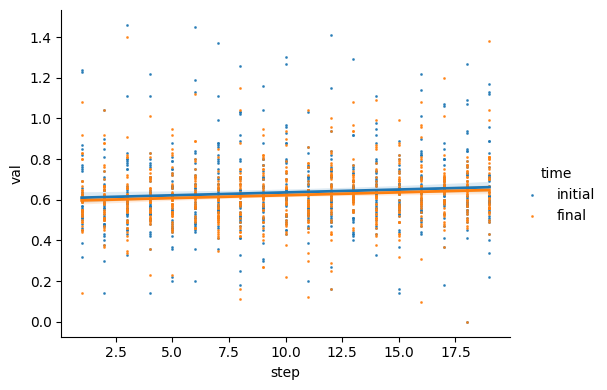

In [ ]:
sns.lmplot(wm.drop(wm.loc[wm.val > 1.5].index), x='step', y='val', hue ='time',            
           scatter_kws={"s": 1}, line_kws={"lw": 2}, 
           height=4, aspect=1.33)

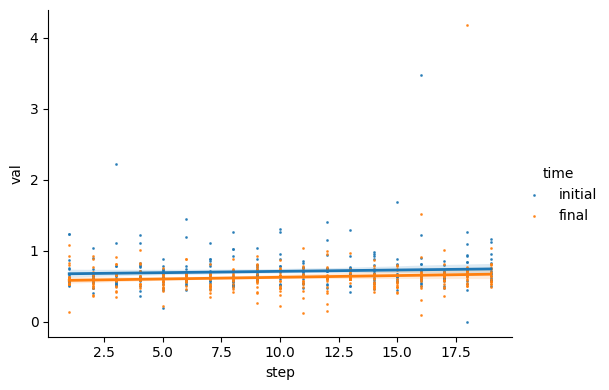

In [111]:
sns.lmplot(wm.drop(wm.loc[wm.group == 'B'].index), x='step', y='val', hue ='time',            
           scatter_kws={"s": 1}, line_kws={"lw": 2}, 
           height=4, aspect=1.33)

<Axes: xlabel='step', ylabel='val'>

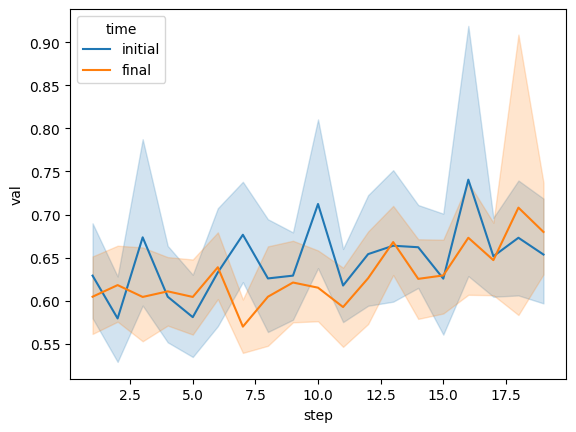

In [ ]:
sns.lineplot(wm, x='step', y='val', hue ='time')

<Axes: xlabel='step', ylabel='val'>

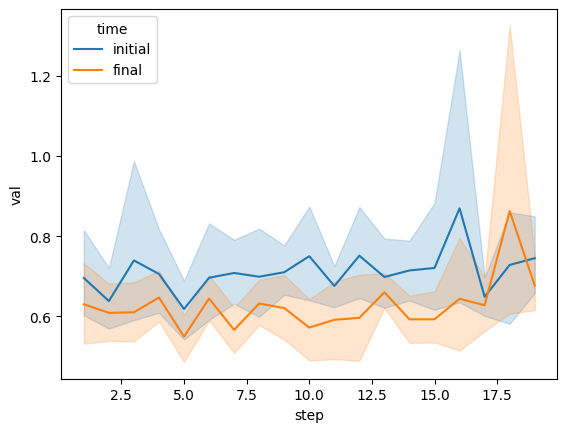

In [109]:
sns.lineplot(wm.drop(wm.loc[wm.group=='B'].index), x='step', y='val', hue ='time')

<Axes: xlabel='step', ylabel='val'>

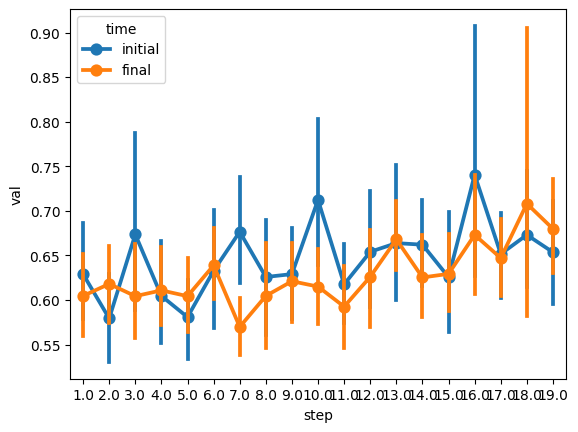

In [ ]:
sns.pointplot(wm, x="step", y="val", hue="time")

<Axes: xlabel='step', ylabel='val'>

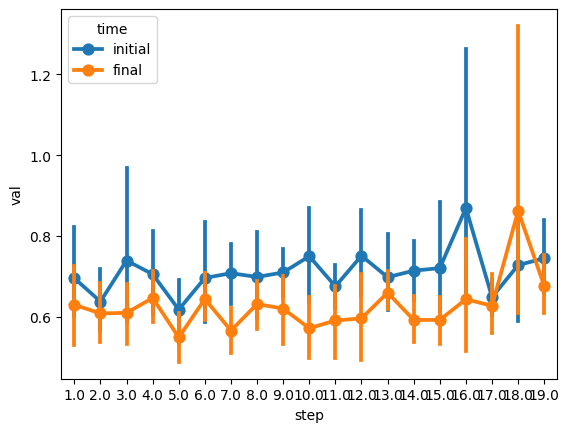

In [110]:
sns.pointplot(wm.drop(wm.loc[wm.group=='B'].index), x="step", y="val", hue="time")

<Axes: xlabel='time', ylabel='total'>

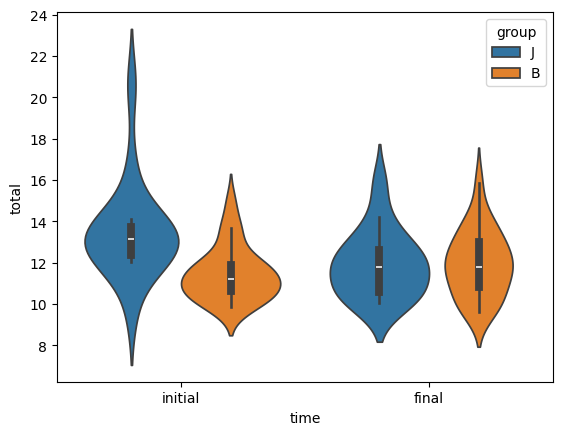

In [108]:
sns.violinplot(w, x="time", y="total", hue='group')

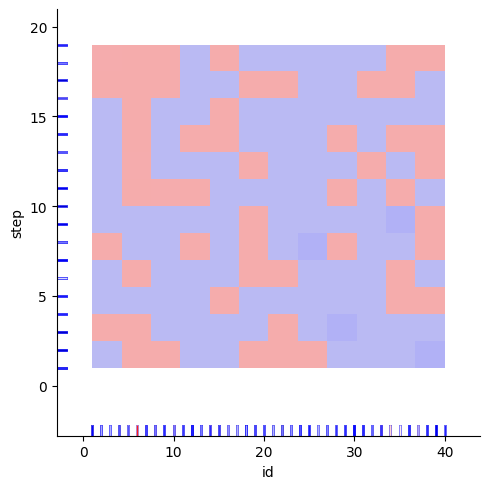

In [106]:
sns.displot(wm.drop(wm.loc[wm.val > 2].index), x='id', y='step', hue='val', rug='True', palette='seismic', legend=False)